In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [8]:
# DAX 40 constituents – using Xetra .DE suffix required by yfinance
dax_tickers = [
    "ADS.DE", "AIR.DE", "ALV.DE", "BAS.DE", "BAYN.DE",
    "BEI.DE", "BMW.DE", "BNR.DE", "CON.DE", "1COV.DE",
    "DTGE.DE", "DBK.DE", "DHL.DE", "DTE.DE", "DTG.DE",
    "ENR.DE", "EOAN.DE", "FRE.DE", "FME.DE", "HNR1.DE",
    "HEI.DE", "HEN3.DE", "IFX.DE", "INL.DE", "MBG.DE",
    "MRK.DE", "MTX.DE", "MUV2.DE", "NDA.DE", "P911.DE",
    "PAH3.DE", "QIA.DE", "RHM.DE", "RWE.DE", "SAP.DE",
    "SHL.DE", "SIE.DE", "SY1.DE", "VNA.DE", "VOW3.DE"
]

print(f"Loaded {len(dax_tickers)} tickers")

Loaded 40 tickers


In [11]:
# DAX 40 constituents – using Xetra .DE suffix required by yfinance
dax_tickers = [
    "ADS.DE", "AIR.DE", "ALV.DE", "BAS.DE", "BAYN.DE",
    "BEI.DE", "BMW.DE", "BNR.DE", "CON.DE", "1COV.DE",
    "CBK.DE", "DBK.DE", "DHL.DE", "DTE.DE", "DTG.DE",
    "ENR.DE", "EOAN.DE", "FRE.DE", "FME.DE", "HNR1.DE",
    "HEI.DE", "HEN3.DE", "IFX.DE", "INL.DE", "MBG.DE",
    "MRK.DE", "MTX.DE", "MUV2.DE", "NDA.DE", "P911.DE",
    "PAH3.DE", "QIA.DE", "RHM.DE", "RWE.DE", "SAP.DE",
    "SHL.DE", "SIE.DE", "SY1.DE", "VNA.DE", "VOW3.DE"
]

print(f"Loaded {len(dax_tickers)} tickers")

Loaded 40 tickers


In [12]:
# Dropping companies with missing core valuation metrics
# Negative P/E excluded – indicates losses, not meaningful for this screen
df_clean = df.dropna(subset=['P/E Ratio', 'ROE (%)', 'Debt/Equity'])
df_clean = df_clean[df_clean['P/E Ratio'] > 0]
df_clean = df_clean.sort_values('ROE (%)', ascending=False).reset_index(drop=True)

print(f"{len(df_clean)} companies after cleaning\n")

display_cols = ['Company', 'Sector', 'P/E Ratio', 'P/B Ratio', 'ROE (%)', 'Debt/Equity', 'EV/EBITDA', 'Market Cap (B€)']
df_clean[display_cols].round(2)

32 companies after cleaning



,Company,Sector,P/E Ratio,P/B Ratio,ROE (%),Debt/Equity,EV/EBITDA,Market Cap (B€)
0,MTU Aero Engines AG N,Industrials,18.66,4.36,26.32,55.50,12.19,19.0
1,adidas AG N,Consumer Cyclical,19.01,4.39,22.96,90.68,11.36,25.3
2,RHEINMETALL AG I,Industrials,87.69,16.10,22.42,47.17,39.78,75.6
3,Airbus SE A,Industrials,26.99,5.36,21.62,54.42,16.91,140.0
4,HANNOVER RUECK SE NA O.N.,Financial Services,12.13,2.49,20.55,32.52,6.21,30.0
5,Siemens Energy AG N,Industrials,73.01,11.98,20.25,33.02,37.07,134.9
6,MUENCHENER RUECKVERS.-GES. AG N,Financial Services,11.07,2.05,18.50,22.24,NaN,69.6
7,SAP SE I,Technology,27.80,4.44,16.12,16.59,17.72,197.5
8,DEUTSCHE POST AG N,Industrials,15.23,2.36,15.83,121.50,9.56,53.9
9,DEUTSCHE TELEKOM AG N,Communication Services,16.66,2.55,15.64,159.08,7.76,158.8


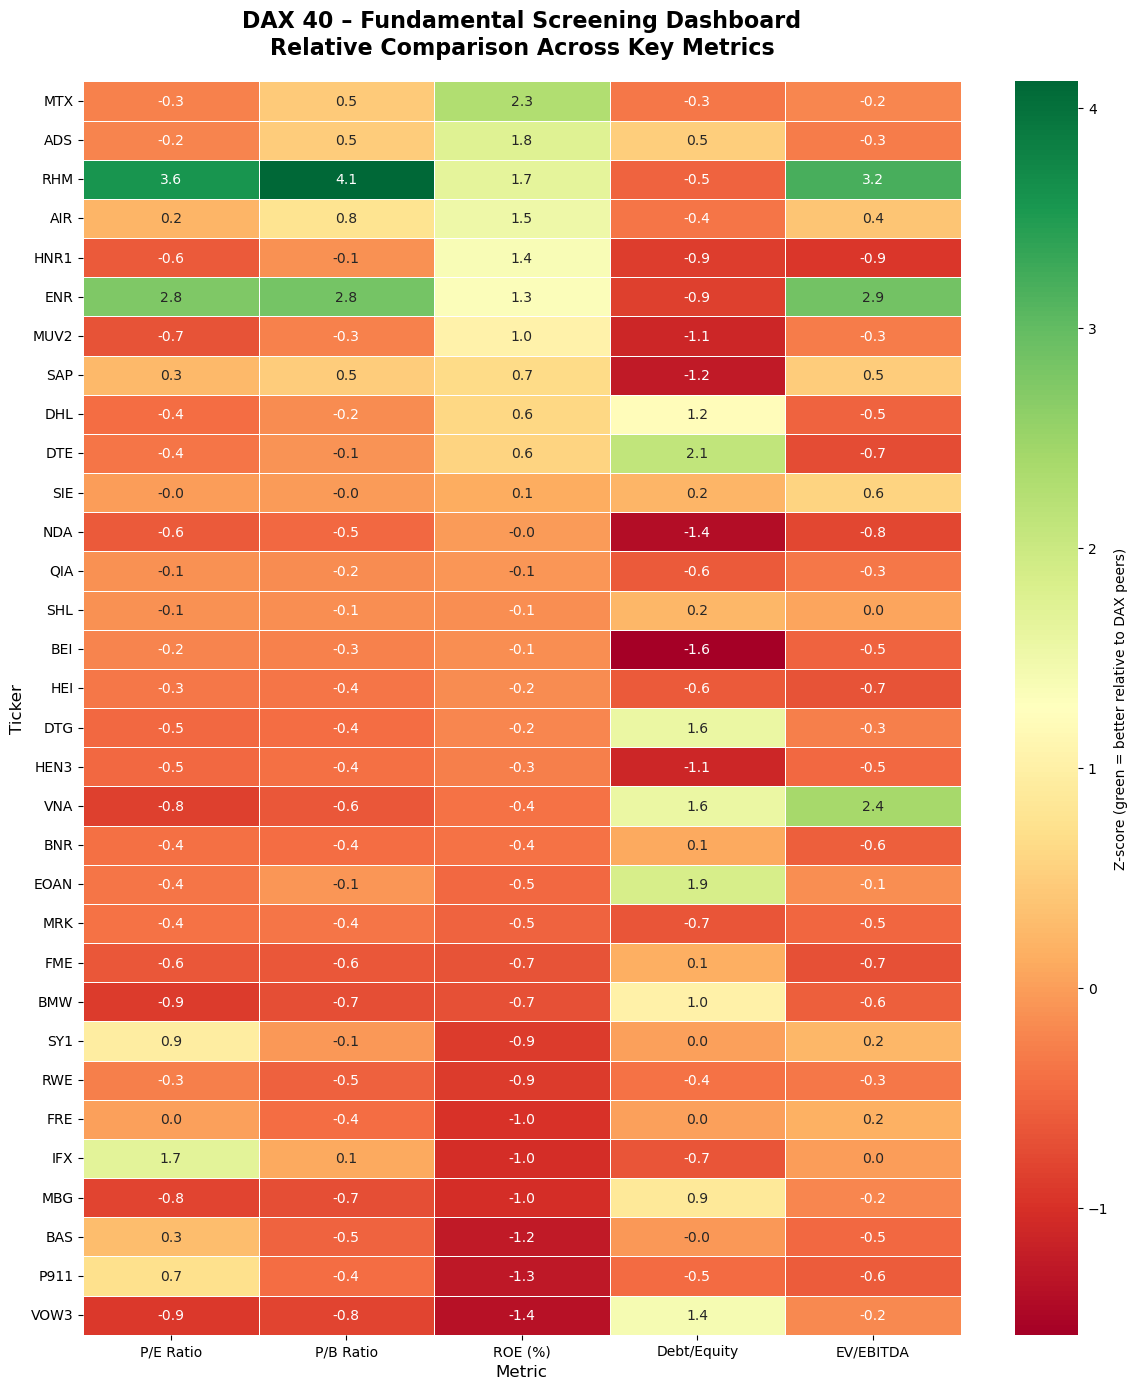

Chart saved to data/01_fundamental_heatmap.png


In [13]:
os.makedirs('data', exist_ok=True)

metrics = ['P/E Ratio', 'P/B Ratio', 'ROE (%)', 'Debt/Equity', 'EV/EBITDA']
heatmap_data = df_clean[['Ticker'] + metrics].set_index('Ticker')

# Missing values filled with column median to preserve all companies in the visual
heatmap_data = heatmap_data.apply(lambda x: x.fillna(x.median()))

# Z-score normalization – ensures metrics with different scales are visually comparable
heatmap_normalized = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

fig, ax = plt.subplots(figsize=(12, 14))

sns.heatmap(
    heatmap_normalized,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Z-score (green = better relative to DAX peers)'}
)

ax.set_title(
    "DAX 40 – Fundamental Screening Dashboard\nRelative Comparison Across Key Metrics",
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Ticker", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('data/01_fundamental_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/01_fundamental_heatmap.png")